In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'C:\Jupyter_notebook\PandasNumPyCourse\data\retail store sales\retail_store_sales_dirty.csv')

In [3]:
df.info() # checking if there are no more missing values in item column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [4]:
df.head() # checking the first 5 rows of the data frame
# первые 5 строк данных

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [5]:
df['Item'].isnull().sum() # checking if there are no more missing values in item column
# проверка на наличие пропущенных значений в столбце Item

np.int64(1213)

In [6]:
df[df['Item'].isnull()] ### rows with missing values in item column
# строки с пропущенными значениями в колонке Item

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
5,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.0,200.0,Credit Card,Online,2023-11-30,NaN
7,TXN_1372952,CUST_21,Furniture,NaN,33.5,NaN,NaN,Digital Wallet,In-store,2024-04-02,True
11,TXN_5422631,CUST_09,Milk Products,NaN,NaN,8.0,52.0,Digital Wallet,In-store,2025-01-12,True
15,TXN_1809665,CUST_14,Beverages,NaN,24.5,NaN,NaN,Credit Card,In-store,2022-05-11,NaN
17,TXN_9634894,CUST_15,Milk Products,NaN,NaN,10.0,275.0,Digital Wallet,Online,2022-04-17,NaN
...,...,...,...,...,...,...,...,...,...,...,...
12527,TXN_1069238,CUST_23,Food,NaN,5.0,NaN,NaN,Digital Wallet,In-store,2022-08-13,False
12552,TXN_4823896,CUST_05,Milk Products,NaN,8.0,NaN,NaN,Cash,In-store,2022-07-21,False
12556,TXN_4397672,CUST_04,Beverages,NaN,41.0,NaN,NaN,Credit Card,Online,2024-11-28,True
12562,TXN_7422454,CUST_07,Butchers,NaN,33.5,NaN,NaN,Cash,Online,2023-04-15,NaN


In [7]:
df['Item'] = df['Item'].fillna('Unknown') ### filling missing values in item column with 'Unknown'
# заполнение пропущенных значений в колонке Item на 'Unknown'

In [8]:
df.info() # checking if there are no more missing values in item column
# проверка правильности формата колонки Transaction Date

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              12575 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [9]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], format='%Y-%m-%d')
 # converting transaction date column to datetime format
 # конвертация колонки Transaction Date в формат datetime

In [10]:
df.info() # checking if there are no more missing values in item column
# проверка правильности формата колонки Transaction Date

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    12575 non-null  object        
 1   Customer ID       12575 non-null  object        
 2   Category          12575 non-null  object        
 3   Item              12575 non-null  object        
 4   Price Per Unit    11966 non-null  float64       
 5   Quantity          11971 non-null  float64       
 6   Total Spent       11971 non-null  float64       
 7   Payment Method    12575 non-null  object        
 8   Location          12575 non-null  object        
 9   Transaction Date  12575 non-null  datetime64[ns]
 10  Discount Applied  8376 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(7)
memory usage: 1.1+ MB


In [11]:
df[df['Total Spent'].isnull() & df['Price Per Unit'].notnull() & df['Quantity'].notnull()]
### rows with missing values in price per unit column
# строки с пропущенными значениями в колонке Price Per Unit при том 
# что в колонках Total Spent и Quantity есть значения    


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied


In [12]:
# проверка правильности колонки 
# Total Spent на основе формулы Total Spent == Price Per Unit * Quantity
temp_check = df['Price Per Unit'] * df['Quantity'] 
# creating a temporary variable to check if the total price column is correct
# создание временной переменной для проверки правильности колонки total price

In [13]:
mismatch = df[df['Total Spent'] != temp_check] 
# creating a new data frame with rows where total spent is not equal to price per unit multiplied by quantity
# создание нового датафрейма с строками, где total spent не равно price per unit умноженному на quantity

In [14]:
mismatch.head() 
# checking the first 5 rows of the mismatch data frame
# проверка первых 5 строк датафрейма mismatch

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
5,TXN_7482416,CUST_09,Patisserie,Unknown,NaN,10.0,200.0,Credit Card,Online,2023-11-30,NaN
7,TXN_1372952,CUST_21,Furniture,Unknown,33.5,NaN,NaN,Digital Wallet,In-store,2024-04-02,True
11,TXN_5422631,CUST_09,Milk Products,Unknown,NaN,8.0,52.0,Digital Wallet,In-store,2025-01-12,True
15,TXN_1809665,CUST_14,Beverages,Unknown,24.5,NaN,NaN,Credit Card,In-store,2022-05-11,NaN
17,TXN_9634894,CUST_15,Milk Products,Unknown,NaN,10.0,275.0,Digital Wallet,Online,2022-04-17,NaN


In [15]:
df.loc[df['Price Per Unit'].isnull(), 'Price Per Unit'] = df['Total Spent'] / df['Quantity']
# filling missing values in price per unit column with total spent divided by quantity
# заполнение пропущенных значений в колонке Price Per Unit на Total Spent деленное на Quantity

In [16]:
df.info() # checking if there are no more missing values in price per unit column
# проверка на наличие пропущенных значений в колонке Price Per Unit

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    12575 non-null  object        
 1   Customer ID       12575 non-null  object        
 2   Category          12575 non-null  object        
 3   Item              12575 non-null  object        
 4   Price Per Unit    12575 non-null  float64       
 5   Quantity          11971 non-null  float64       
 6   Total Spent       11971 non-null  float64       
 7   Payment Method    12575 non-null  object        
 8   Location          12575 non-null  object        
 9   Transaction Date  12575 non-null  datetime64[ns]
 10  Discount Applied  8376 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(7)
memory usage: 1.1+ MB


In [17]:
(df == 0).sum() # checking if there are zero values in the data frame
# проверка на наличие нулевых значений в датафрейме

Transaction ID         0
Customer ID            0
Category               0
Item                   0
Price Per Unit         0
Quantity               0
Total Spent            0
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4157
dtype: int64

In [18]:
df['weekday'] = df['Transaction Date'].dt.day_name() 
# creating a new column with the name of the day of the week based on the transaction date column
# создание новой колонки с названием дня недели на основе колонки Transaction Date 

In [19]:
df.head() # checking if there are no more missing values in price per unit column

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,weekday
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,Monday
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,Sunday
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,Wednesday
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN,Saturday
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,Sunday


In [20]:
# grouping the data frame by weekday column and calculating the total spent for each day of the week
weekly_sales = df.groupby('weekday')['Total Spent'].sum()
# группировка датафрейма по колонке weekday и подсчет общей суммы продаж для каждого дня недели

In [21]:
print(weekly_sales.sort_values(ascending=False))
# вывод общей суммы продаж для каждого дня недели, отсортированной по убыванию

weekday
Friday       232786.0
Sunday       225991.0
Saturday     224191.0
Tuesday      219650.0
Thursday     219380.5
Wednesday    216982.0
Monday       213090.5
Name: Total Spent, dtype: float64


In [22]:
df.duplicated().sum() # checking if there are duplicate rows in the data frame
# проверка на наличие дублирующихся строк в датафрейме

np.int64(0)

In [23]:
df = df.drop_duplicates() # removing duplicate rows from the data frame
# удаление дублирующихся строк из датафрейма

In [24]:
df.info() # checking if there are no more missing values in price per unit column
# проверка на наличие пропущенных значений в колонке Price Per Unit

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    12575 non-null  object        
 1   Customer ID       12575 non-null  object        
 2   Category          12575 non-null  object        
 3   Item              12575 non-null  object        
 4   Price Per Unit    12575 non-null  float64       
 5   Quantity          11971 non-null  float64       
 6   Total Spent       11971 non-null  float64       
 7   Payment Method    12575 non-null  object        
 8   Location          12575 non-null  object        
 9   Transaction Date  12575 non-null  datetime64[ns]
 10  Discount Applied  8376 non-null   object        
 11  weekday           12575 non-null  object        
dtypes: datetime64[ns](1), float64(3), object(8)
memory usage: 1.2+ MB


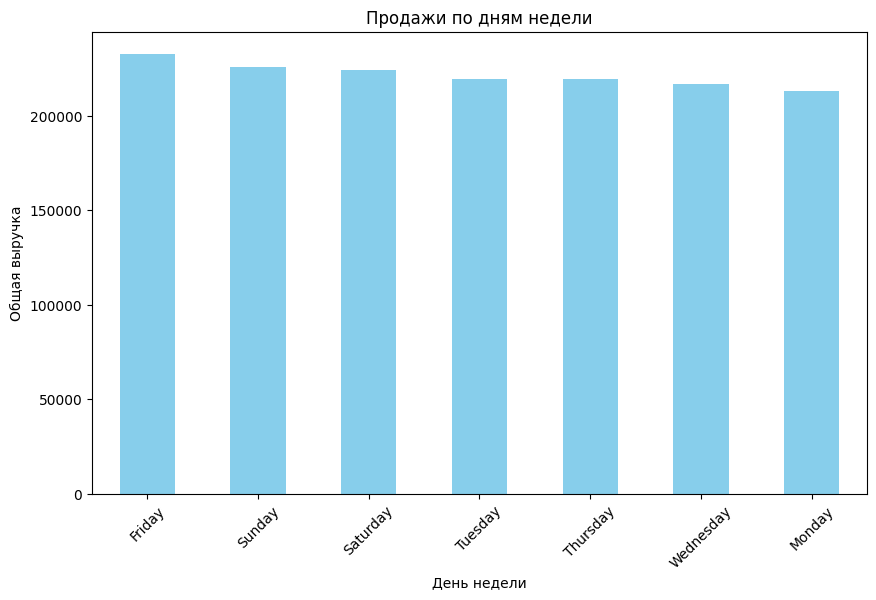

In [25]:


# Используем твой результат группировки (убедись, что переменная weekly_sales создана)
# Сортируем для красоты графика
weekly_sales = weekly_sales.sort_values(ascending=False)

# Строим столбчатую диаграмму
plt.figure(figsize=(10, 6))
weekly_sales.plot(kind='bar', color='skyblue')

plt.title('Продажи по дням недели')
plt.xlabel('День недели')
plt.ylabel('Общая выручка')
plt.xticks(rotation=45) # Поворачиваем названия, чтобы не слипались
plt.show()

In [26]:
df.to_csv('retail_sales_cleaned.csv', index=False)